## MSD from LAMMPS fix

Let's use this to find the terminal relaxation time.

Each timestep is 0.005 $\tau$ and each snapshot is 10000 apart from each other.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

filename = "data/msd/prodmsd_chainlength_30_N_beads_24000_gaussA_20_r0_0.35_gaussB_10_seed_12345.dat"

times = []
msd = []
msd_calculated = []
msd_std = []
counts = []

# columns are chunk_id, dx^2, dy^2, dz^2, RMSD^2
with open(filename, 'r') as f:
    while True:
        line = f.readline()
        if not line:
            break
        if line.startswith("#"):
            # print("skipping header line")
            continue
        # print("processing line:", line)
        current_timestep, num_entries = line.strip().split() # get the timestep from the next line after the header
        # print(f"Current timestep: {current_timestep}, Number of entries: {num_entries}")
        dx_values = np.zeros(int(num_entries))
        dy_values = np.zeros(int(num_entries))
        dz_values = np.zeros(int(num_entries))
        RMSD_values = np.zeros(int(num_entries))
        for i in range(int(num_entries)):
            _, dx_values[i], dy_values[i], dz_values[i], RMSD_values[i] = next(f).strip().split() # read the RMSD value from the 5th column of each line
        rms_calculated = np.mean(dx_values + dy_values + dz_values)

        # average over all chains for this timestep
        msd_calculated.append(np.mean(rms_calculated))
        times.append(current_timestep)
        msd.append(np.mean(RMSD_values))
        msd_std.append(np.std(RMSD_values))
        counts.append(int(num_entries))

In [36]:
times = np.array(times, dtype=float)
times = times - times[0] # shift time to start from 0
times = times * 0.005
msd = np.array(msd, dtype=float)
msd_calculated = np.array(msd_calculated, dtype=float)
msd_std = np.array(msd_std, dtype=float)
counts = np.array(counts, dtype=int)
# print(times)

In [43]:
msd_file = "data/msd/msd.csv"
df = pd.read_csv(msd_file, header=None, names=["time", "msd"])


13703 13703


/tmp/ipykernel_1539067/3133199774.py:2: RuntimeWarning: invalid value encountered in divide
  plt.loglog(times, msd/np.sqrt(times), label="MSD from LAMMPS")


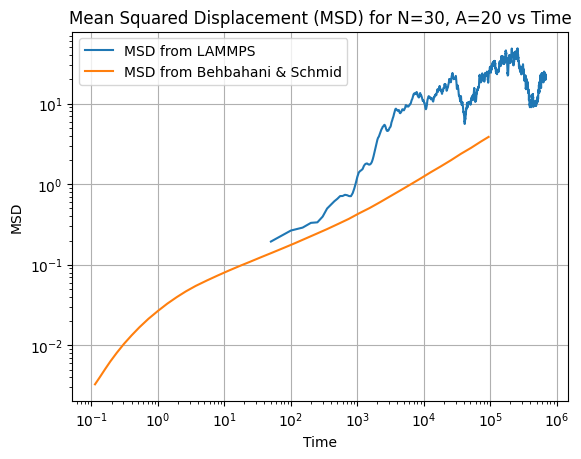

In [45]:
print(len(times), len(msd))
plt.loglog(times, msd/np.sqrt(times), label="MSD from LAMMPS")
plt.loglog(df["time"], df["msd"], label="MSD from Behbahani & Schmid")
# plt.plot(times, msd_calculated, label="MSD calculated from dx, dy, dz")
plt.title("Mean Squared Displacement (MSD) for N=30, A=20 vs Time")
plt.xlabel("Time")
plt.ylabel("MSD")
plt.grid()
plt.legend()
plt.show()